#**Step 1- Ingestion (PySpark)**

##1. Mount Google drive

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. Instrall java and PySpark

In [ ]:
!apt-get update -qq
!apt-get install openjdk-11-jdk -y -qq

!pip install -q pyspark==4.0.0 findspark

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libatspi2.0-0:amd64.
(Reading database ... 117528 files and directories currently installed.)
Preparing to unpack .../00-libatspi2.0-0_2.44.0-3_amd64.deb ...
Unpacking libatspi2.0-0:amd64 (2.44.0-3) ...
Selecting previously unselected package libxtst6:amd64.
Preparing to unpack .../01-libxtst6_2%3a1.2.3-1build4_amd64.deb ...
Unpacking libxtst6:amd64 (2:1.2.3-1build4) ...
Selecting previously unselected package session-migration.
Preparing to unpack .../02-session-migration_0.3.6_amd64.deb ...
Unpacking session-migration (0.3.6) ...
Selecting previously unselected package gsettings-desktop-schemas.
Preparing to unpack .../03-gsettings-desktop-schemas_42.0-1ubuntu1_all.deb ...
Unpacking gsettings-desktop-schemas (42.0-1ubuntu1) ...
Selecting previously unselected

##3. Start a Spark session

In [ ]:
import os
import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("YelpIngestion") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.session.timeZone", "UTC") \
    .getOrCreate()

spark

##4.Point to files/ list directory(Confirm paths)

In [ ]:
BASE_PATH = "/content/drive/MyDrive/Yelp/"
import os
print("Listing files in:", BASE_PATH)
print(os.listdir(BASE_PATH))

Listing files in: /content/drive/MyDrive/Yelp/
['business.json', 'checkin.json']


##5.Load JSON files (spark.read.json)

In [ ]:
# load business
business_path= BASE_PATH + "business.json"
business_df = spark.read.json(business_path)

# load user
checkin_path = BASE_PATH + "checkin.json"
checkin_df = spark.read.json(checkin_path)






##6.basic info

In [ ]:
#Business- column names
print(business_df.columns)

#How many raws in Business dataset
print ("Number of Raws:", business_df.count())

['address', 'attributes', 'business_id', 'categories', 'city', 'hours', 'is_open', 'latitude', 'longitude', 'name', 'postal_code', 'review_count', 'stars', 'state']
Number of Raws: 150346


In [ ]:
#checkin-Column names
print (checkin_df.columns)

#how many raws in checkin dataset
print ("Number of Raws:", checkin_df.count())

['business_id', 'date']
Number of Raws: 131930


In [ ]:
business_df.printSchema()

root
 |-- address: string (nullable = true)
 |-- attributes: struct (nullable = true)
 |    |-- AcceptsInsurance: string (nullable = true)
 |    |-- AgesAllowed: string (nullable = true)
 |    |-- Alcohol: string (nullable = true)
 |    |-- Ambience: string (nullable = true)
 |    |-- BYOB: string (nullable = true)
 |    |-- BYOBCorkage: string (nullable = true)
 |    |-- BestNights: string (nullable = true)
 |    |-- BikeParking: string (nullable = true)
 |    |-- BusinessAcceptsBitcoin: string (nullable = true)
 |    |-- BusinessAcceptsCreditCards: string (nullable = true)
 |    |-- BusinessParking: string (nullable = true)
 |    |-- ByAppointmentOnly: string (nullable = true)
 |    |-- Caters: string (nullable = true)
 |    |-- CoatCheck: string (nullable = true)
 |    |-- Corkage: string (nullable = true)
 |    |-- DietaryRestrictions: string (nullable = true)
 |    |-- DogsAllowed: string (nullable = true)
 |    |-- DriveThru: string (nullable = true)
 |    |-- GoodForDancing: str

In [ ]:
checkin_df.printSchema()

root
 |-- business_id: string (nullable = true)
 |-- date: string (nullable = true)



#**Step 2- Data Preprocessing (PySpark)**

##PART A — BUSINESS DATASET CLEANING

##1:Basic sanity check

In [ ]:
print("Total rows:", business_df.count())
business_df.printSchema()


Total rows: 150346
root
 |-- address: string (nullable = true)
 |-- attributes: struct (nullable = true)
 |    |-- AcceptsInsurance: string (nullable = true)
 |    |-- AgesAllowed: string (nullable = true)
 |    |-- Alcohol: string (nullable = true)
 |    |-- Ambience: string (nullable = true)
 |    |-- BYOB: string (nullable = true)
 |    |-- BYOBCorkage: string (nullable = true)
 |    |-- BestNights: string (nullable = true)
 |    |-- BikeParking: string (nullable = true)
 |    |-- BusinessAcceptsBitcoin: string (nullable = true)
 |    |-- BusinessAcceptsCreditCards: string (nullable = true)
 |    |-- BusinessParking: string (nullable = true)
 |    |-- ByAppointmentOnly: string (nullable = true)
 |    |-- Caters: string (nullable = true)
 |    |-- CoatCheck: string (nullable = true)
 |    |-- Corkage: string (nullable = true)
 |    |-- DietaryRestrictions: string (nullable = true)
 |    |-- DogsAllowed: string (nullable = true)
 |    |-- DriveThru: string (nullable = true)
 |    |-- 

##2:Handle obvious nulls

In [ ]:
from pyspark.sql.functions import col

business_df = business_df.filter(
    col("business_id").isNotNull() &
    col("stars").isNotNull() &
    col("review_count").isNotNull()
)


##3.Clean categorical text columns

### 3.1Normalize city & state

In [ ]:
from pyspark.sql.functions import trim, upper

business_df = business_df.withColumn("city", trim(col("city")))
business_df = business_df.withColumn("state", upper(trim(col("state"))))


### 3.2 Handle missing categories

In [ ]:
from pyspark.sql.functions import when, lit

business_df = business_df.withColumn(
    "categories",
    when(col("categories").isNull(), lit("Unknown"))
    .otherwise(col("categories"))
)


## 4. Create category helper columns

### 4.1 Primary (main) category

In [ ]:
from pyspark.sql.functions import split

business_df = business_df.withColumn(
    "primary_category",
    split(col("categories"), ",").getItem(0)
)


### 4.2 Category count (richness of business)

In [ ]:
from pyspark.sql.functions import size

business_df = business_df.withColumn(
    "num_categories",
    size(split(col("categories"), ","))
)


## 5. Hours struct (basic helper only)


In [ ]:
from pyspark.sql.functions import size

business_df = business_df.withColumn(
    "num_categories",
    size(split(col("categories"), ","))
)


## 6. Location sanity check

In [ ]:
business_df = business_df.filter(
    (col("latitude").between(-90, 90)) &
    (col("longitude").between(-180, 180))
)


## 7. Final business dataset schema (cleaned)

In [ ]:
business_df.printSchema()
print("Final business rows:", business_df.count())


root
 |-- address: string (nullable = true)
 |-- attributes: struct (nullable = true)
 |    |-- AcceptsInsurance: string (nullable = true)
 |    |-- AgesAllowed: string (nullable = true)
 |    |-- Alcohol: string (nullable = true)
 |    |-- Ambience: string (nullable = true)
 |    |-- BYOB: string (nullable = true)
 |    |-- BYOBCorkage: string (nullable = true)
 |    |-- BestNights: string (nullable = true)
 |    |-- BikeParking: string (nullable = true)
 |    |-- BusinessAcceptsBitcoin: string (nullable = true)
 |    |-- BusinessAcceptsCreditCards: string (nullable = true)
 |    |-- BusinessParking: string (nullable = true)
 |    |-- ByAppointmentOnly: string (nullable = true)
 |    |-- Caters: string (nullable = true)
 |    |-- CoatCheck: string (nullable = true)
 |    |-- Corkage: string (nullable = true)
 |    |-- DietaryRestrictions: string (nullable = true)
 |    |-- DogsAllowed: string (nullable = true)
 |    |-- DriveThru: string (nullable = true)
 |    |-- GoodForDancing: str

## PART B — CHECK-IN DATASET CLEANING

### 1. Basic check

In [ ]:
print("Total rows:", checkin_df.count())
checkin_df.printSchema()


Total rows: 131930
root
 |-- business_id: string (nullable = true)
 |-- date: string (nullable = true)



2. Count number of check ins per row

In [ ]:
from pyspark.sql.functions import split, size

checkin_df = checkin_df.withColumn(
    "num_checkins",
    size(split(col("date"), ","))
)


In [ ]:
print (checkin_df.columns)

['business_id', 'date', 'num_checkins']


###  first 10 raws in checking dataset

In [ ]:
checkin_df.select("num_checkins").show(10)

+------------+
|num_checkins|
+------------+
|          11|
|          10|
|           2|
|          10|
|          26|
|          32|
|          24|
|          34|
|           7|
|          82|
+------------+
only showing top 10 rows


### missing value check

In [ ]:
from pyspark.sql.functions import col, sum

checkin_df.select(
    sum(col('business_id').isNull().cast('int')).alias('missing_business_id'),
    sum(col('date').isNull().cast('int')).alias('missing_date'),
    sum(col('num_checkins').isNull().cast('int')).alias('missing_num_checkins')
).show()

+-------------------+------------+--------------------+
|missing_business_id|missing_date|missing_num_checkins|
+-------------------+------------+--------------------+
|                  0|           0|                   0|
+-------------------+------------+--------------------+



In [ ]:
checkin_df.printSchema()
print("Final Checkin rows:", checkin_df.count())

root
 |-- business_id: string (nullable = true)
 |-- date: string (nullable = true)
 |-- num_checkins: integer (nullable = true)

Final Checkin rows: 131930


## save clean business dataset.

Save CLEANED datasets as JSON (Spark-friendly)

Business dataset-JSON(keep STRUCTs)

In [ ]:
business_df.coalesce(1).write \
    .mode("overwrite") \
    .json("/content/drive/MyDrive/yelp_project/cleaned/business_json")


In [ ]:
checkin_df.coalesce(1).write \
    .mode("overwrite") \
    .json("/content/drive/MyDrive/yelp_project/cleaned/checkin_json")


In [ ]:
checkin_df.show(10)

+--------------------+--------------------+------------+
|         business_id|                date|num_checkins|
+--------------------+--------------------+------------+
|---kPU91CF4Lq2-Wl...|2020-03-13 21:10:...|          11|
|--0iUa4sNDFiZFrAd...|2010-09-13 21:43:...|          10|
|--30_8IhuyMHbSOcN...|2013-06-14 23:29:...|           2|
|--7PUidqRWpRSpXeb...|2011-02-15 17:12:...|          10|
|--7jw19RH9JKXgFoh...|2014-04-21 20:42:...|          26|
|--8IbOsAAxjKRoYsB...|2015-06-06 01:03:...|          32|
|--9osgUCSDUWUkoTL...|2015-06-13 02:00:...|          24|
|--ARBQr1WMsTWiwOK...|2014-12-12 00:44:...|          34|
|--FWWsIwxRwuw9vIM...|2010-09-11 16:28:...|           7|
|--FcbSxK1AoEtEAxO...|2017-08-18 19:43:...|          82|
+--------------------+--------------------+------------+
only showing top 10 rows


Prepare Tableau-friendly versions (DROP STRUCTS)

Drop STRUCT columns from Business

In [ ]:
business_df= business_df.drop("attributes", "hours")


In [ ]:
business_df.printSchema()

root
 |-- address: string (nullable = true)
 |-- business_id: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- city: string (nullable = true)
 |-- is_open: long (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- name: string (nullable = true)
 |-- postal_code: string (nullable = true)
 |-- review_count: long (nullable = true)
 |-- stars: double (nullable = true)
 |-- state: string (nullable = true)
 |-- primary_category: string (nullable = true)
 |-- num_categories: integer (nullable = true)



In [ ]:
print("Business_df rows:", business_df.count())

print("checkin_df rows;", checkin_df.count())


Business_df rows: 150346
checkin_df rows; 131930


In [ ]:
business_df.show(10)

+--------------------+--------------------+--------------------+--------------+-------+----------+------------+--------------------+-----------+------------+-----+-----+--------------------+--------------+
|             address|         business_id|          categories|          city|is_open|  latitude|   longitude|                name|postal_code|review_count|stars|state|    primary_category|num_categories|
+--------------------+--------------------+--------------------+--------------+-------+----------+------------+--------------------+-----------+------------+-----+-----+--------------------+--------------+
|1616 Chapala St, ...|Pns2l4eNsfO8kk83d...|Doctors, Traditio...| Santa Barbara|      0|34.4266787|-119.7111968|Abby Rappoport, L...|      93101|           7|  5.0|   CA|             Doctors|             6|
|87 Grasso Plaza S...|mpf3x-BjTdTEA3yCZ...|Shipping Centers,...|        Affton|      1| 38.551126|  -90.335695|       The UPS Store|      63123|          15|  3.0|   MO|    Shi

In [ ]:
checkin_df.show(10)

+--------------------+--------------------+------------+
|         business_id|                date|num_checkins|
+--------------------+--------------------+------------+
|---kPU91CF4Lq2-Wl...|2020-03-13 21:10:...|          11|
|--0iUa4sNDFiZFrAd...|2010-09-13 21:43:...|          10|
|--30_8IhuyMHbSOcN...|2013-06-14 23:29:...|           2|
|--7PUidqRWpRSpXeb...|2011-02-15 17:12:...|          10|
|--7jw19RH9JKXgFoh...|2014-04-21 20:42:...|          26|
|--8IbOsAAxjKRoYsB...|2015-06-06 01:03:...|          32|
|--9osgUCSDUWUkoTL...|2015-06-13 02:00:...|          24|
|--ARBQr1WMsTWiwOK...|2014-12-12 00:44:...|          34|
|--FWWsIwxRwuw9vIM...|2010-09-11 16:28:...|           7|
|--FcbSxK1AoEtEAxO...|2017-08-18 19:43:...|          82|
+--------------------+--------------------+------------+
only showing top 10 rows


#**Step 3- Descriptive Analysis (PySpark+ Pandas+ SQL)**

In [ ]:

# Check schema and few rows
business_df.printSchema()
business_df.show(5, truncate=80)

checkin_df.printSchema()
checkin_df.show(5, truncate=80)



root
 |-- address: string (nullable = true)
 |-- business_id: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- city: string (nullable = true)
 |-- is_open: long (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- name: string (nullable = true)
 |-- postal_code: string (nullable = true)
 |-- review_count: long (nullable = true)
 |-- stars: double (nullable = true)
 |-- state: string (nullable = true)
 |-- primary_category: string (nullable = true)
 |-- num_categories: integer (nullable = true)

+-------------------------------+----------------------+--------------------------------------------------------------------------------+-------------+-------+----------+------------+------------------------+-----------+------------+-----+-----+-----------------+--------------+
|                        address|           business_id|                                                                      categories|         c

In [ ]:
print("Total rows:", business_df.count())


Total rows: 150346


In [ ]:
# Path to cleaned checkin JSON folder
#checkin_json_path = "/content/drive/MyDrive/yelp_project/cleaned/checkin_json"

# Load JSON into Spark DataFrame
#checkin_df = spark.read.option("multiline", "true").json(checkin_json_path)

# Check schema and few rows
#checkin_df.printSchema()
#checkin_df.show(5, truncate=80)


In [ ]:
business_df.columns

['address',
 'business_id',
 'categories',
 'city',
 'is_open',
 'latitude',
 'longitude',
 'name',
 'postal_code',
 'review_count',
 'stars',
 'state',
 'primary_category',
 'num_categories']

In [ ]:
checkin_df.columns

['business_id', 'date', 'num_checkins']

In [ ]:
business_df.show(10)

+--------------------+--------------------+--------------------+--------------+-------+----------+------------+--------------------+-----------+------------+-----+-----+--------------------+--------------+
|             address|         business_id|          categories|          city|is_open|  latitude|   longitude|                name|postal_code|review_count|stars|state|    primary_category|num_categories|
+--------------------+--------------------+--------------------+--------------+-------+----------+------------+--------------------+-----------+------------+-----+-----+--------------------+--------------+
|1616 Chapala St, ...|Pns2l4eNsfO8kk83d...|Doctors, Traditio...| Santa Barbara|      0|34.4266787|-119.7111968|Abby Rappoport, L...|      93101|           7|  5.0|   CA|             Doctors|             6|
|87 Grasso Plaza S...|mpf3x-BjTdTEA3yCZ...|Shipping Centers,...|        Affton|      1| 38.551126|  -90.335695|       The UPS Store|      63123|          15|  3.0|   MO|    Shi

In [ ]:
checkin_df.show(10)

+--------------------+--------------------+------------+
|         business_id|                date|num_checkins|
+--------------------+--------------------+------------+
|---kPU91CF4Lq2-Wl...|2020-03-13 21:10:...|          11|
|--0iUa4sNDFiZFrAd...|2010-09-13 21:43:...|          10|
|--30_8IhuyMHbSOcN...|2013-06-14 23:29:...|           2|
|--7PUidqRWpRSpXeb...|2011-02-15 17:12:...|          10|
|--7jw19RH9JKXgFoh...|2014-04-21 20:42:...|          26|
|--8IbOsAAxjKRoYsB...|2015-06-06 01:03:...|          32|
|--9osgUCSDUWUkoTL...|2015-06-13 02:00:...|          24|
|--ARBQr1WMsTWiwOK...|2014-12-12 00:44:...|          34|
|--FWWsIwxRwuw9vIM...|2010-09-11 16:28:...|           7|
|--FcbSxK1AoEtEAxO...|2017-08-18 19:43:...|          82|
+--------------------+--------------------+------------+
only showing top 10 rows


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid")


## Step 1: Load & Integrate Datasets Using SQL

In [ ]:
# Register DataFrames as temporary views for SQL
business_df.createOrReplaceTempView("business")
checkin_df.createOrReplaceTempView("checkin")


joined_df = spark.sql("""
    SELECT
        b.business_id,
        first(b.address) AS address,
        first(b.categories) AS categories,
        first(b.city) AS city,
        first(b.is_open) AS is_open,
        first(b.latitude) AS latitude,
        first(b.longitude) AS longitude,
        first(b.name) AS name,
        first(b.num_categories) AS num_categories,
        first(b.postal_code) AS postal_code,
        first(b.primary_category) AS primary_category,
        first(b.review_count) AS review_count,
        first(b.stars) AS stars,
        first(b.state) AS state,
        COALESCE(SUM(c.num_checkins), 0) AS total_checkins
    FROM business b
    LEFT JOIN checkin c
        ON b.business_id = c.business_id
    GROUP BY b.business_id
""")




In [ ]:
joined_df.count()
joined_df.select("total_checkins").describe().show()


+-------+-----------------+
|summary|   total_checkins|
+-------+-----------------+
|  count|           150346|
|   mean|88.84090697457864|
| stddev|392.1576969977807|
|    min|                0|
|    max|            52144|
+-------+-----------------+



In [ ]:
print("Joined rows:", joined_df.count())
joined_df.printSchema()
joined_df.show(5, truncate=80)


Joined rows: 150346
root
 |-- business_id: string (nullable = true)
 |-- address: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- city: string (nullable = true)
 |-- is_open: long (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- name: string (nullable = true)
 |-- num_categories: integer (nullable = true)
 |-- postal_code: string (nullable = true)
 |-- primary_category: string (nullable = true)
 |-- review_count: long (nullable = true)
 |-- stars: double (nullable = true)
 |-- state: string (nullable = true)
 |-- total_checkins: long (nullable = false)

+----------------------+--------------------+-------------------------------------------------------+---------------+-------+----------+-----------+---------------------------------+--------------+-----------+----------------+------------+-----+-----+--------------+
|           business_id|             address|                                             cate

I aggregate checkins per business (SUM(num_checkins)) and join it to the business dataset for richer insights.

## Distribution of Businesses by City

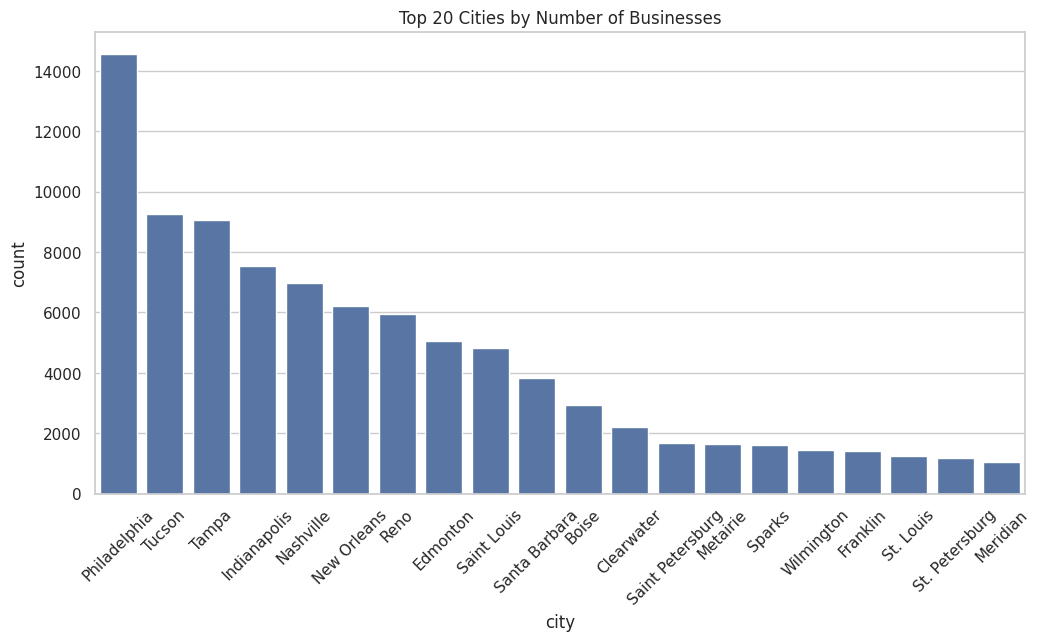

In [ ]:
city_counts = joined_df.groupBy("city").count().orderBy("count", ascending=False)
city_counts_pd = city_counts.toPandas()

plt.figure(figsize=(12,6))
sns.barplot(x="city", y="count", data=city_counts_pd.head(20))
plt.xticks(rotation=45)
plt.title("Top 20 Cities by Number of Businesses")
plt.show()

## Distribution of Business Ratings

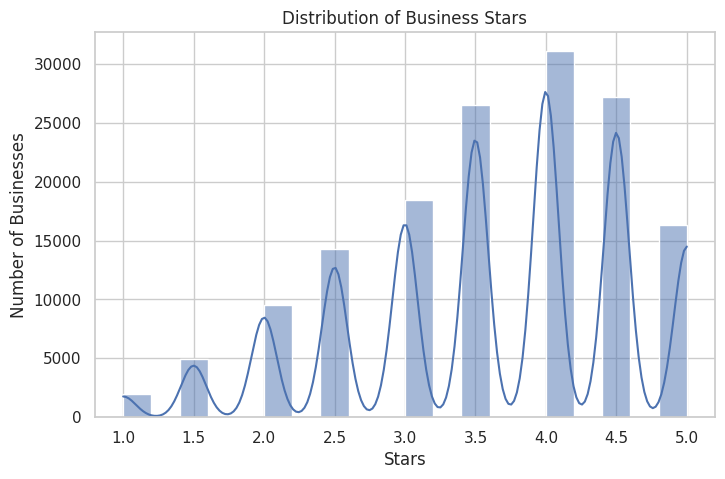

In [ ]:
ratings_pd = joined_df.select("stars").toPandas()

plt.figure(figsize=(8,5))
sns.histplot(ratings_pd["stars"], bins=20, kde=True)
plt.title("Distribution of Business Stars")
plt.xlabel("Stars")
plt.ylabel("Number of Businesses")
plt.show()


## Most Popular Categories

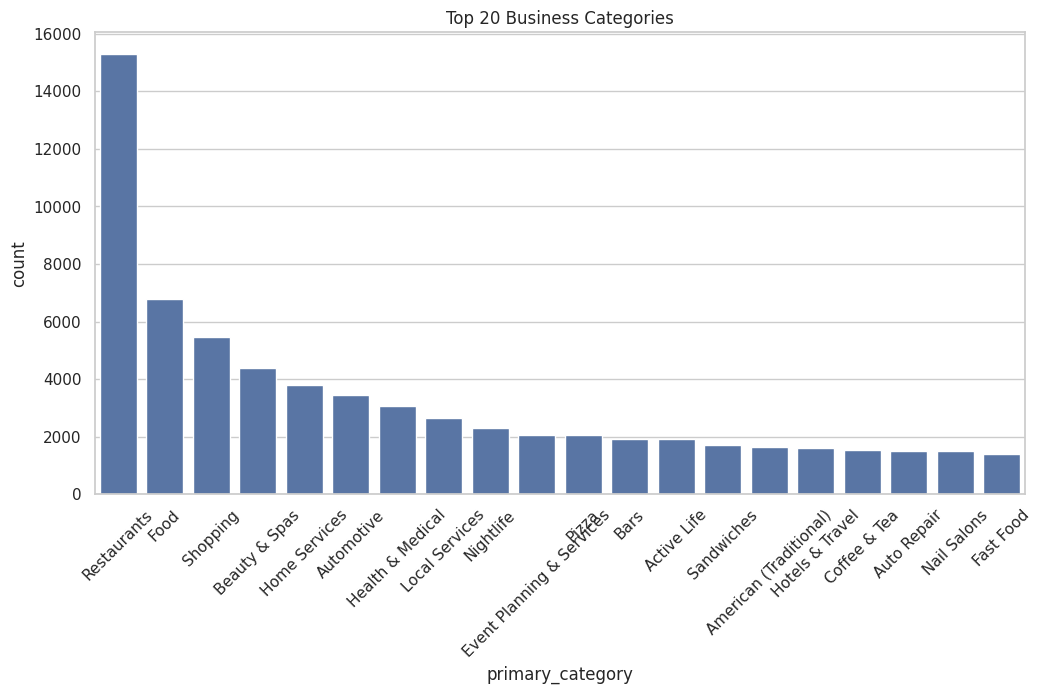

In [ ]:
category_counts = joined_df.groupBy("primary_category").count().orderBy("count", ascending=False)
category_counts_pd = category_counts.toPandas()

plt.figure(figsize=(12,6))
sns.barplot(x="primary_category", y="count", data=category_counts_pd.head(20))
plt.xticks(rotation=45)
plt.title("Top 20 Business Categories")
plt.show()


## Check-ins vs Stars

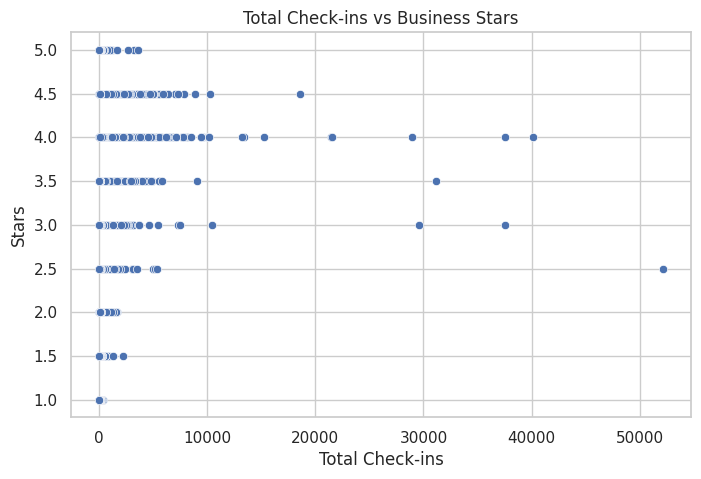

In [ ]:
checkins_stars_pd = joined_df.select("stars", "total_checkins").toPandas()

plt.figure(figsize=(8,5))
sns.scatterplot(x="total_checkins", y="stars", data=checkins_stars_pd)
plt.title("Total Check-ins vs Business Stars")
plt.xlabel("Total Check-ins")
plt.ylabel("Stars")
plt.show()


## Review Count Distribution

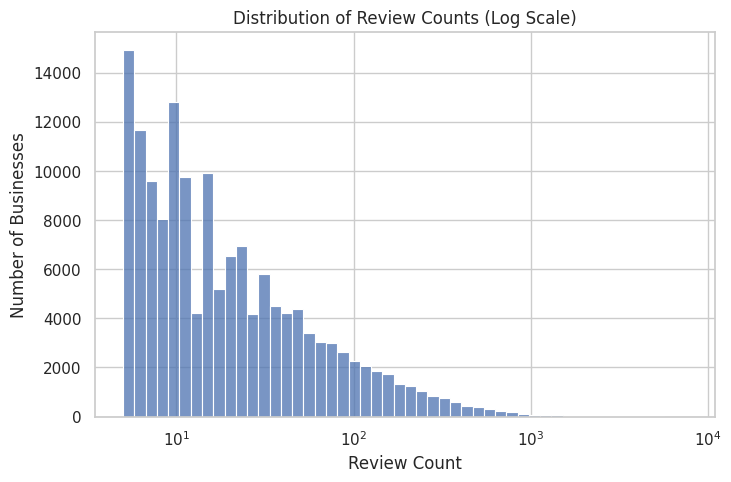

In [ ]:
review_counts_pd = joined_df.select("review_count").toPandas()

plt.figure(figsize=(8,5))
sns.histplot(review_counts_pd["review_count"], bins=50, log_scale=True)
plt.title("Distribution of Review Counts (Log Scale)")
plt.xlabel("Review Count")
plt.ylabel("Number of Businesses")
plt.show()


## Total Check-ins per Business

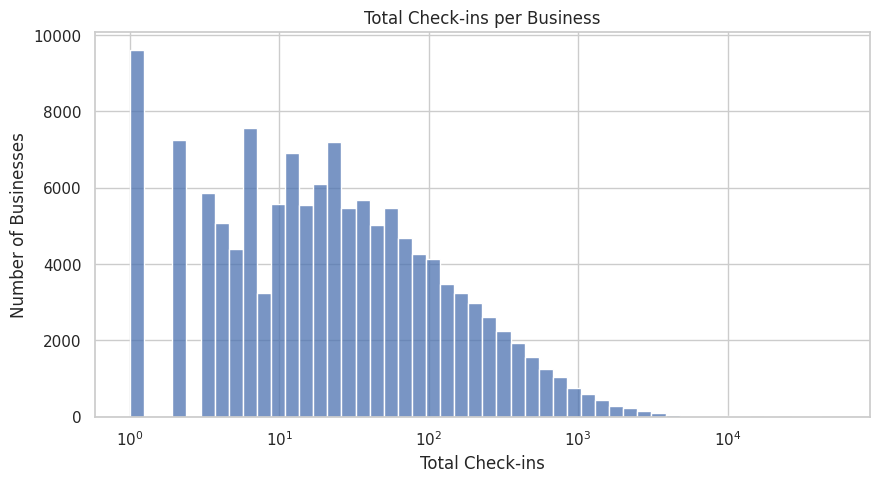

In [ ]:
checkins_summary = checkin_df.groupBy("business_id").sum("num_checkins").orderBy("sum(num_checkins)", ascending=False)
checkins_summary_pd = checkins_summary.toPandas()

plt.figure(figsize=(10,5))
sns.histplot(checkins_summary_pd["sum(num_checkins)"], bins=50, log_scale=True)
plt.title("Total Check-ins per Business")
plt.xlabel("Total Check-ins")
plt.ylabel("Number of Businesses")
plt.show()


## Check-ins by Day of Week (requires extracting day from date)

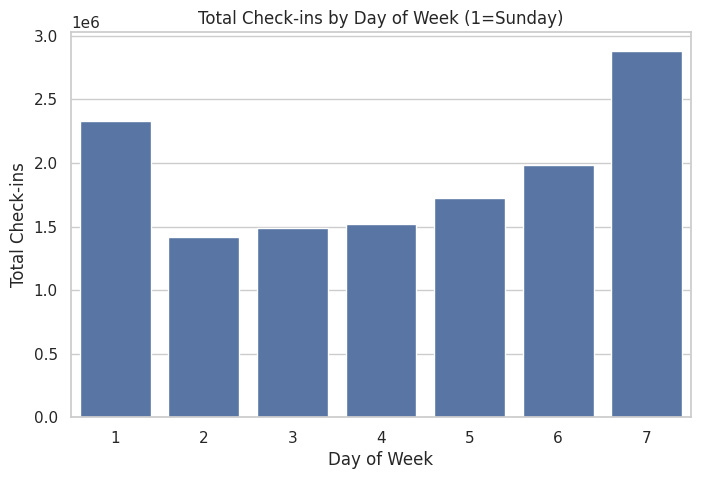

In [ ]:
from pyspark.sql.functions import dayofweek, to_date

checkin_df = checkin_df.withColumn("checkin_date", to_date("date"))
checkin_df = checkin_df.withColumn("day_of_week", dayofweek("checkin_date"))

day_counts = checkin_df.groupBy("day_of_week").sum("num_checkins").orderBy("day_of_week")
day_counts_pd = day_counts.toPandas()

plt.figure(figsize=(8,5))
sns.barplot(x="day_of_week", y="sum(num_checkins)", data=day_counts_pd)
plt.title("Total Check-ins by Day of Week (1=Sunday)")
plt.xlabel("Day of Week")
plt.ylabel("Total Check-ins")
plt.show()


## Stars vs Check-ins by City

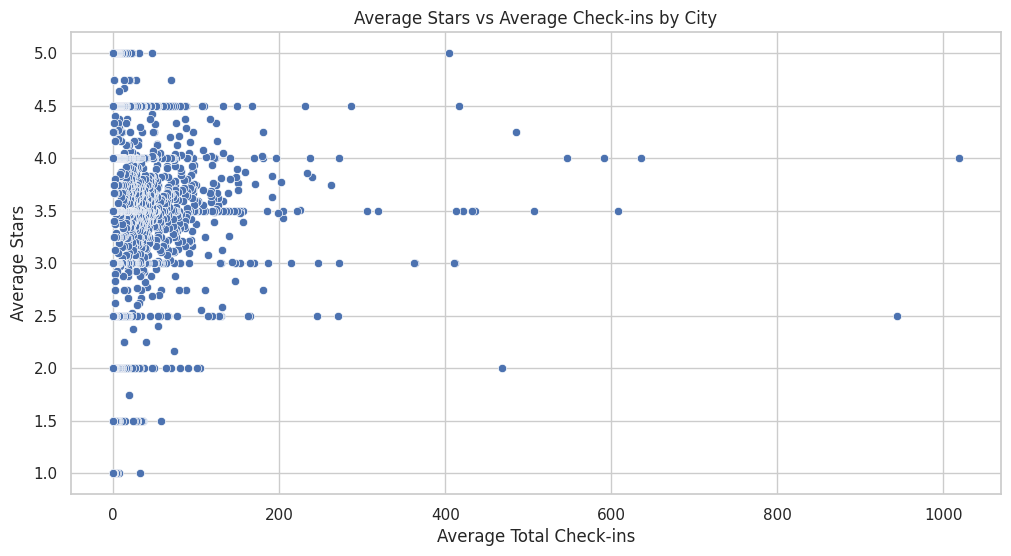

In [ ]:
city_checkins = joined_df.groupBy("city").avg("stars", "total_checkins").orderBy("avg(total_checkins)", ascending=False)
city_checkins_pd = city_checkins.toPandas()

plt.figure(figsize=(12,6))
sns.scatterplot(x="avg(total_checkins)", y="avg(stars)", data=city_checkins_pd)
plt.title("Average Stars vs Average Check-ins by City")
plt.xlabel("Average Total Check-ins")
plt.ylabel("Average Stars")
plt.show()


##Check-ins vs Primary Category

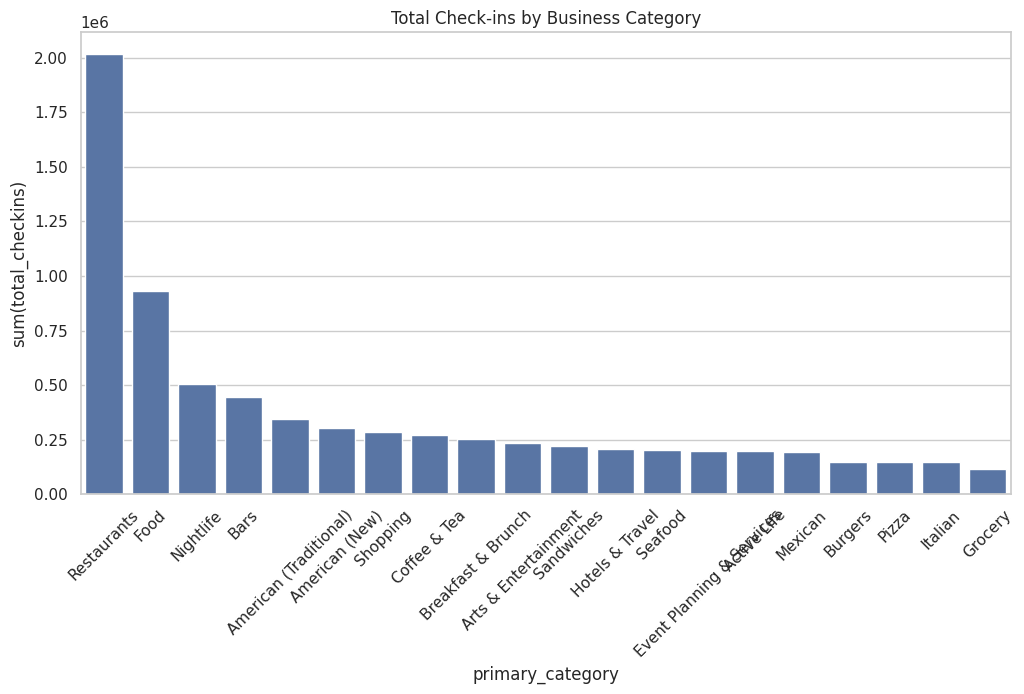

In [ ]:
category_checkins = joined_df.groupBy("primary_category").sum("total_checkins").orderBy("sum(total_checkins)", ascending=False)
category_checkins_pd = category_checkins.toPandas()

plt.figure(figsize=(12,6))
sns.barplot(x="primary_category", y="sum(total_checkins)", data=category_checkins_pd.head(20))
plt.xticks(rotation=45)
plt.title("Total Check-ins by Business Category")
plt.show()


with out plotting

## 1 Business landscape analysis

Total businesses

In [ ]:
business_df.count()


150346

Businesses per state

In [ ]:
from pyspark.sql.functions import desc

business_df.groupBy("state") \
    .count() \
    .orderBy(desc("count")) \
    .show(10)

+-----+-----+
|state|count|
+-----+-----+
|   PA|34039|
|   FL|26330|
|   TN|12056|
|   IN|11247|
|   MO|10913|
|   LA| 9924|
|   AZ| 9912|
|   NJ| 8536|
|   NV| 7715|
|   AB| 5573|
+-----+-----+
only showing top 10 rows


Businesses per city

In [ ]:
business_df.groupBy("city") \
    .count() \
    .orderBy(desc("count")) \
    .show(10)


+-------------+-----+
|         city|count|
+-------------+-----+
| Philadelphia|14570|
|       Tucson| 9252|
|        Tampa| 9051|
| Indianapolis| 7543|
|    Nashville| 6974|
|  New Orleans| 6209|
|         Reno| 5937|
|     Edmonton| 5054|
|  Saint Louis| 4828|
|Santa Barbara| 3834|
+-------------+-----+
only showing top 10 rows


## 2 Business status (Open vs Closed)

Open vs close %

In [ ]:
business_df.groupBy("is_open").count().show()


+-------+------+
|is_open| count|
+-------+------+
|      0| 30648|
|      1|119698|
+-------+------+



Closed rate by category

In [ ]:
business_df.groupBy("primary_category", "is_open") \
    .count() \
    .orderBy(desc("count")) \
    .show(10)


+----------------+-------+-----+
|primary_category|is_open|count|
+----------------+-------+-----+
|     Restaurants|      1| 9963|
|     Restaurants|      0| 5327|
|            Food|      1| 4953|
|        Shopping|      1| 4462|
|   Beauty & Spas|      1| 3778|
|   Home Services|      1| 3522|
|      Automotive|      1| 3159|
|Health & Medical|      1| 2851|
|  Local Services|      1| 2391|
|            Food|      0| 1830|
+----------------+-------+-----+
only showing top 10 rows


## 3 Category based analysis

Unique categories

In [ ]:
business_df.select("primary_category").distinct().count()


1160

avg number of categories per business

In [ ]:
from pyspark.sql.functions import avg
business_df.select(avg("num_categories")).show()

+-------------------+
|avg(num_categories)|
+-------------------+
|  4.447707288521144|
+-------------------+



Distribution of num_categories

In [ ]:
business_df.groupBy("num_categories") \
    .count() \
    .orderBy("num_categories") \
    .show()


+--------------+-----+
|num_categories|count|
+--------------+-----+
|             1|  484|
|             2|32563|
|             3|27065|
|             4|26354|
|             5|23450|
|             6|16233|
|             7|10189|
|             8| 5869|
|             9| 3598|
|            10| 2024|
|            11| 1083|
|            12|  647|
|            13|  373|
|            14|  178|
|            15|   88|
|            16|   60|
|            17|   41|
|            18|   21|
|            19|   10|
|            20|    4|
+--------------+-----+
only showing top 20 rows


category popularity

In [ ]:
from pyspark.sql.functions import count, avg, desc

business_df.groupBy("primary_category") \
    .agg(
        count("*").alias("business_count"),
        avg("stars").alias("avg_stars"),
        avg("review_count").alias("avg_reviews")
    ) \
    .orderBy(desc("business_count")) \
    .show(10)

+--------------------+--------------+------------------+------------------+
|    primary_category|business_count|         avg_stars|       avg_reviews|
+--------------------+--------------+------------------+------------------+
|         Restaurants|         15290| 3.464780902550687| 75.19921517331589|
|                Food|          6783|3.6679197994987467|50.157157599882055|
|            Shopping|          5480| 3.591058394160584|18.381569343065692|
|       Beauty & Spas|          4385| 3.764310148232611| 24.00296465222349|
|       Home Services|          3793|3.4360664381755868|14.501186395992619|
|          Automotive|          3449|3.4940562481878805|19.965207306465643|
|    Health & Medical|          3058|3.5727599738391107| 14.78155657292348|
|      Local Services|          2642| 3.634557153671461|16.224072672218018|
|           Nightlife|          2291|3.6281099956350937| 97.13531209079005|
|Event Planning & ...|          2067|3.5457184325108853|50.790517658442184|
+-----------

High rated business per category

In [ ]:
business_df.withColumn(
    "high_rating",
    when(col("stars") >= 4, 1).otherwise(0)
).groupBy("primary_category") \
 .agg(avg("high_rating").alias("pct_high_rated")) \
 .orderBy(desc("pct_high_rated")) \
 .show(10)


+--------------------+--------------+
|    primary_category|pct_high_rated|
+--------------------+--------------+
|           Mediators|           1.0|
|  Concierge Medicine|           1.0|
|      Senior Centers|           1.0|
|     Pet Photography|           1.0|
|  Lactation Services|           1.0|
|   Botanical Gardens|           1.0|
|      Land Surveying|           1.0|
|Pole Dancing Classes|           1.0|
| Architectural Tours|           1.0|
|       Videographers|           1.0|
+--------------------+--------------+
only showing top 10 rows


## Ratings and reviews analysis

Star rating distribution

In [ ]:
business_df.groupBy("stars").count().orderBy("stars").show()


+-----+-----+
|stars|count|
+-----+-----+
|  1.0| 1986|
|  1.5| 4932|
|  2.0| 9527|
|  2.5|14316|
|  3.0|18453|
|  3.5|26519|
|  4.0|31125|
|  4.5|27181|
|  5.0|16307|
+-----+-----+



avg star by city

In [ ]:
business_df.groupBy("city") \
    .agg(avg("stars").alias("avg_stars")) \
    .orderBy(desc("avg_stars")) \
    .show(10)


+----------------+---------+
|            city|avg_stars|
+----------------+---------+
|          Eagle,|      5.0|
|        MERIDIAN|      5.0|
|         Lutz fl|      5.0|
|   Picture Rocks|      5.0|
|      Ellisville|      5.0|
|       Covington|      5.0|
|     Los Angeles|      5.0|
|    Webster Grvs|      5.0|
|MIDDLE CITY WEST|      5.0|
|          COLMAR|      5.0|
+----------------+---------+
only showing top 10 rows


Correlation: stars vs review_count

In [ ]:
business_df.stat.corr("stars", "review_count")


0.05987551581506613

## Location Intelligence

avg stars by state

In [ ]:
business_df.groupBy("state") \
    .agg(avg("stars").alias("avg_stars")) \
    .orderBy(desc("avg_stars")) \
    .show()


+-----+------------------+
|state|         avg_stars|
+-----+------------------+
|   MT|               5.0|
|   UT|               4.5|
|   VT|               4.5|
|   SD|               4.5|
|   HI|              4.25|
|   CO|               4.0|
|  XMS|               4.0|
|   CA|3.9967326542379396|
|   NV|3.7368762151652626|
|   ID|3.7076337586747257|
|   LA| 3.679161628375655|
|   FL|3.6109570831750855|
|   AZ|3.5920096852300243|
|   IN|3.5882457544234017|
|   PA|3.5730191838773173|
|   TN| 3.571499668214997|
|   MO| 3.546091817098873|
|   WA|               3.5|
|   NJ|3.4591143392689783|
|   AB| 3.447514803516957|
+-----+------------------+
only showing top 20 rows


Business density by state

In [ ]:
business_df.groupBy("state").count().orderBy(desc("count")).show()


+-----+-----+
|state|count|
+-----+-----+
|   PA|34039|
|   FL|26330|
|   TN|12056|
|   IN|11247|
|   MO|10913|
|   LA| 9924|
|   AZ| 9912|
|   NJ| 8536|
|   NV| 7715|
|   AB| 5573|
|   CA| 5203|
|   ID| 4467|
|   DE| 2265|
|   IL| 2145|
|   TX|    4|
|   CO|    3|
|   WA|    2|
|   HI|    2|
|   MA|    2|
|   MI|    1|
+-----+-----+
only showing top 20 rows


## 6 Check in dataset analysis

Total check ins

In [ ]:
checkin_df.select(sum("num_checkins")).show()


+-----------------+
|sum(num_checkins)|
+-----------------+
|         13356875|
+-----------------+



avg checkins per business

In [ ]:
checkin_df.groupBy("business_id") \
    .agg(sum("num_checkins").alias("total_checkins")) \
    .select(avg("total_checkins")) \
    .show()


+-------------------+
|avg(total_checkins)|
+-------------------+
| 101.24213598120215|
+-------------------+



## 7 Temporal checkins patterns

checkins by year

In [ ]:
from pyspark.sql.functions import year, sum

checkin_df.withColumn("year", year("date")) \
    .groupBy("year") \
    .agg(sum("num_checkins").alias("total_checkins")) \
    .orderBy("year") \
    .show()

+----+--------------+
|year|total_checkins|
+----+--------------+
|2009|           986|
|2010|       7362977|
|2011|       1616912|
|2012|       1004066|
|2013|        858205|
|2014|        705097|
|2015|        579112|
|2016|        451470|
|2017|        318276|
|2018|        236586|
|2019|        139726|
|2020|         55483|
|2021|         27759|
|2022|           220|
+----+--------------+



checkins by day of week

In [ ]:
checkin_df.withColumn("day", dayofweek("date")) \
    .groupBy("day") \
    .agg(sum("num_checkins").alias("total_checkins")) \
    .orderBy("day") \
    .show()


+---+--------------+
|day|total_checkins|
+---+--------------+
|  1|       2332263|
|  2|       1420175|
|  3|       1486357|
|  4|       1520937|
|  5|       1727946|
|  6|       1985145|
|  7|       2884052|
+---+--------------+



## Integration-Business+ checkin

Aggregate check-ins per business

In [ ]:
checkin_agg = checkin_df.groupBy("business_id") \
    .agg(sum("num_checkins").alias("total_checkins"))


join with business

In [ ]:
biz_checkin_df = business_df.join(
    checkin_agg,
    on="business_id",
    how="left"
).fillna(0, subset=["total_checkins"])


## 9 Engagement vs Quality

avg stars by traffic level

In [ ]:
biz_checkin_df.withColumn(
    "traffic_level",
    when(col("total_checkins") >= 1000, "High")
    .when(col("total_checkins") >= 200, "Medium")
    .otherwise("Low")
).groupBy("traffic_level") \
 .agg(avg("stars").alias("avg_stars")) \
 .show()


+-------------+------------------+
|traffic_level|         avg_stars|
+-------------+------------------+
|         High|3.8770532603285215|
|          Low|3.5860244062885736|
|       Medium| 3.664520085863232|
+-------------+------------------+



Correlation: reviews vs check-ins

In [ ]:
biz_checkin_df.stat.corr("review_count", "total_checkins")


0.6749223674497384

## 10 Business Success Profile

Define successful business

In [ ]:
biz_checkin_df = biz_checkin_df.withColumn(
    "successful",
    when(
        (col("stars") >= 4) &
        (col("review_count") >= biz_checkin_df.approxQuantile("review_count",[0.5],0.01)[0]) &
        (col("total_checkins") >= biz_checkin_df.approxQuantile("total_checkins",[0.5],0.01)[0]),
        1
    ).otherwise(0)
)


What categories succeed most?

In [ ]:
biz_checkin_df.groupBy("primary_category") \
    .agg(avg("successful").alias("success_rate")) \
    .orderBy(desc("success_rate")) \
    .show(10)


+--------------------+------------+
|    primary_category|success_rate|
+--------------------+------------+
|          Bocce Ball|         1.0|
|        Bike Parking|         1.0|
|Sport Equipment Hire|         1.0|
|       Nephrologists|         1.0|
|  Himalayan/Nepalese|         1.0|
|            Sicilian|         1.0|
|        Shanghainese|         1.0|
|       Observatories|         1.0|
|       International|         1.0|
|             Iberian|         1.0|
+--------------------+------------+
only showing top 10 rows


#**Step 4- Predictive Modelling**

In [ ]:
# Print schema (column names + data types)
print("Business Dataset Schema:")
business_df.printSchema()

# Count rows
business_rows = business_df.count()
print("Total rows in business_df:", business_rows)


Business Dataset Schema:
root
 |-- address: string (nullable = true)
 |-- business_id: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- city: string (nullable = true)
 |-- is_open: long (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- name: string (nullable = true)
 |-- postal_code: string (nullable = true)
 |-- review_count: long (nullable = true)
 |-- stars: double (nullable = true)
 |-- state: string (nullable = true)
 |-- primary_category: string (nullable = true)
 |-- num_categories: integer (nullable = true)

Total rows in business_df: 150346


In [ ]:
# Print schema (column names + data types)
print("Check-in Dataset Schema:")
checkin_df.printSchema()

# Count rows
checkin_rows = checkin_df.count()
print("Total rows in checkin_df:", checkin_rows)


Check-in Dataset Schema:
root
 |-- business_id: string (nullable = true)
 |-- date: string (nullable = true)
 |-- num_checkins: integer (nullable = true)
 |-- checkin_date: date (nullable = true)
 |-- day_of_week: integer (nullable = true)

Total rows in checkin_df: 131930


## **Prediction Task 1- Predict Business Success**

Imports

In [ ]:
from pyspark.sql.functions import col, when
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml import Pipeline


### Step 1- Create target variable (high_rating)

In [ ]:
#Convert stars into binary label
model_df = business_df.withColumn(
    "high_rating",
    when(col("stars") >= 4, 1).otherwise(0)
)


### Step 2- Select only require columns

In [ ]:
model_df = model_df.select(
    "high_rating",
    "primary_category",
    "city",
    "state",
    "review_count",
    "is_open"
)


### Step 3- Handle missing values

In [ ]:
model_df = model_df.na.drop()


In [ ]:
model_df.count()

150346

### Ste4- Encode categorical variables (Stringlndexer)

In [ ]:
#Tree and linera models need numbers, not strings
cat_cols = ["primary_category", "city", "state"]

indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=c + "_idx",
        handleInvalid="keep"
    )
    for c in cat_cols
]


### Step 5- Assemble feature vector

In [ ]:
# Numeric + indexed categorical features
feature_cols = [
    "review_count",
    "is_open",
    "primary_category_idx",
    "city_idx",
    "state_idx"
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)


### Step 6- Train/ Test split

In [ ]:
train_df, test_df = model_df.randomSplit([0.8, 0.2], seed=60)

print("Train rows:", train_df.count())
print("Test rows:", test_df.count())


Train rows: 120333
Test rows: 30013


### **Step 7- Logistic Regression Model**

#### 7.1 Build pipeline

In [ ]:
lr = LogisticRegression(
    labelCol="high_rating",
    featuresCol="features"
)

lr_pipeline = Pipeline(stages=indexers + [assembler, lr])


#### 7.2 Train model

In [ ]:
lr_model = lr_pipeline.fit(train_df)


#### 7.3 Predict

In [ ]:
lr_predictions = lr_model.transform(test_df)


#### 7.4 **Evaluate (AUC)**

In [ ]:
evaluator = BinaryClassificationEvaluator(
    labelCol="high_rating",
    metricName="areaUnderROC"
)

lr_auc = evaluator.evaluate(lr_predictions)
print("Logistic Regression AUC:", lr_auc)


Logistic Regression AUC: 0.57192994536064


### **Step 8- Random Forest Classifier**

In [ ]:
from pyspark.sql.functions import col, desc, when, lit
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator


#### Limit categories to TOP-100 + OTHER

In [ ]:
# Top 100 most frequent categories
top_categories = business_df.groupBy("primary_category") \
    .count() \
    .orderBy(desc("count")) \
    .limit(100) \
    .select("primary_category") \
    .rdd.flatMap(lambda x: x) \
    .collect()

# Replace rare categories with OTHER
business_df = business_df.withColumn(
    "primary_category_limited",
    when(col("primary_category").isin(top_categories), col("primary_category"))
    .otherwise(lit("OTHER"))
)


In [ ]:
#Create Binary Target (DV)
business_df = business_df.withColumn(
    "high_rating",
    when(col("stars") >= 4, 1).otherwise(0)
)


#### Select modeling columns

In [ ]:
model_df = business_df.select(
    "high_rating",
    "primary_category_limited",
    "review_count",
    "num_categories",
    "is_open"
).na.drop()


#### Train/ Test split

In [ ]:
train_df, test_df = model_df.randomSplit([0.8, 0.2], seed=42)

print("Train rows:", train_df.count())
print("Test rows:", test_df.count())


Train rows: 120127
Test rows: 30219


#### Stringlndexer (category encoding)

In [ ]:
category_indexer = StringIndexer(
    inputCol="primary_category_limited",
    outputCol="primary_category_idx",
    handleInvalid="keep"
)


#### Assemble features

In [ ]:
assembler = VectorAssembler(
    inputCols=[
        "review_count",
        "num_categories",
        "is_open",
        "primary_category_idx"
    ],
    outputCol="features"
)


#### Define Random Forest Model

In [ ]:
rf = RandomForestClassifier(
    labelCol="high_rating",
    featuresCol="features",
    numTrees=100,
    maxDepth=8,
    maxBins=128,     # IMPORTANT for many categories
    seed=42
)


#### Build pipeline

In [ ]:
rf_pipeline = Pipeline(stages=[
    category_indexer,
    assembler,
    rf
])


#### Train Random Forest

In [ ]:
rf_model = rf_pipeline.fit(train_df)


#### Predict on Test data

In [ ]:
rf_predictions = rf_model.transform(test_df)


#### **Evaluate Model (AUC)**

In [ ]:
evaluator = BinaryClassificationEvaluator(
    labelCol="high_rating",
    metricName="areaUnderROC"
)

rf_auc = evaluator.evaluate(rf_predictions)
print("Random Forest AUC:", rf_auc)


Random Forest AUC: 0.6209149955470812


## **Compare models**

In [ ]:
print("MODEL COMPARISON")
print("Logistic Regression AUC:", lr_auc)
print("Random Forest AUC:", rf_auc)


MODEL COMPARISON
Logistic Regression AUC: 0.57192994536064
Random Forest AUC: 0.6209149955470812


#### Feature importance (Random forest)

In [ ]:
rf_stage = rf_model.stages[-1]
importances = rf_stage.featureImportances.toArray()

for f, imp in zip(feature_cols, importances):
    print(f, ":", round(imp, 4))


review_count : 0.219
is_open : 0.1405
primary_category_idx : 0.0855
city_idx : 0.555


## Save the models

In [ ]:
# Random Forest
rf_model.write().overwrite().save("/content/drive/MyDrive/yelp_project/models/rf_business_success")

# Logistic Regression
lr_model.write().overwrite().save("/content/drive/MyDrive/yelp_project/models/lr_business_success")


## #Load the models later

In [ ]:
from pyspark.ml.pipeline import PipelineModel

# Random Forest
rf_model_loaded = PipelineModel.load("/content/drive/MyDrive/yelp_project/models/rf_business_success")

# Logistic Regression
lr_model_loaded = PipelineModel.load("/content/drive/MyDrive/yelp_project/models/lr_business_success")


## **Prediction Task 2- foot traffic prediction**

In [ ]:
# Print schema (column names + data types)
print("Check-in Dataset Schema:")
checkin_df.printSchema()

# Count rows
checkin_rows = checkin_df.count()
print("Total rows in checkin_df:", checkin_rows)

Check-in Dataset Schema:
root
 |-- business_id: string (nullable = true)
 |-- date: string (nullable = true)
 |-- num_checkins: integer (nullable = true)
 |-- checkin_date: date (nullable = true)
 |-- day_of_week: integer (nullable = true)

Total rows in checkin_df: 131930


In [ ]:
from pyspark.sql.functions import col, when
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import RandomForestClassifier, GBTClassifier
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator


### Prepare dataset

In [ ]:
# Create binary target: high_traffic = 1 if num_checkins > median else 0
median_checkins = checkin_df.approxQuantile("num_checkins", [0.5], 0.0)[0]

checkin_df = checkin_df.withColumn(
    "high_traffic",
    when(col("num_checkins") > median_checkins, 1).otherwise(0)
)

# fill nulls in features
checkin_df = checkin_df.fillna({"num_checkins":0, "day_of_week":0})


### Assemble features

In [ ]:
feature_cols = ["num_checkins", "day_of_week"]  # use all available numeric features
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Keep label + features
model_df = assembler.transform(checkin_df).select("high_traffic", "features")


### Train/ test split

In [ ]:
train_df, test_df = model_df.randomSplit([0.8, 0.2], seed=72)
print("Train rows:", train_df.count(), "Test rows:", test_df.count())


Train rows: 105607 Test rows: 26323


### **Random Forest Classifier**

In [ ]:
rf = RandomForestClassifier(
    labelCol="high_traffic",
    featuresCol="features",
    numTrees=100,
    maxDepth=8,
    seed=72
)

rf_model = rf.fit(train_df)
rf_preds = rf_model.transform(test_df)

# Evaluate
evaluator = BinaryClassificationEvaluator(labelCol="high_traffic", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
rf_auc = evaluator.evaluate(rf_preds)
print("Random Forest AUC:", rf_auc)


Random Forest AUC: 0.988611754163244


In [ ]:
importances_traffic = rf_model.featureImportances.toArray()

print("Feature Importances for Foot Traffic Prediction (Random Forest):")
for f, imp in zip(feature_cols, importances_traffic):
    print(f, ":", round(imp, 4))

Feature Importances for Foot Traffic Prediction (Random Forest):
num_checkins : 1.0
day_of_week : 0.0


### **Gradient Boosted tress classifier**

In [ ]:
gbt = GBTClassifier(
    labelCol="high_traffic",
    featuresCol="features",
    maxIter=50,
    maxDepth=6,
    seed=41
)

gbt_model = gbt.fit(train_df)
gbt_preds = gbt_model.transform(test_df)

# Evaluate
gbt_auc = evaluator.evaluate(gbt_preds)
print("GBT AUC:", gbt_auc)


GBT AUC: 0.9995222882268338


### **Model Comparison**

In [ ]:
print("Model Comparison:")
print(f"Random Forest AUC: {rf_auc:.4f}")
print(f"GBT AUC: {gbt_auc:.4f}")

best_model = "Random Forest" if rf_auc > gbt_auc else "GBT"
print("Best Model:", best_model)


Model Comparison:
Random Forest AUC: 0.9886
GBT AUC: 0.9995
Best Model: GBT


### Saving the models

In [ ]:
# Save Random Forest
rf_model.write().overwrite().save("/content/drive/MyDrive/yelp_project/models/rf_foot_traffic")

# Save GBT
gbt_model.write().overwrite().save("/content/drive/MyDrive/yelp_project/models/gbt_foot_traffic")


### #Load later

In [ ]:
from pyspark.ml.pipeline import PipelineModel

rf_model = PipelineModel.load("/content/drive/MyDrive/yelp_project/models/rf_foot_traffic")
gbt_model = PipelineModel.load("/content/drive/MyDrive/yelp_project/models/gbt_foot_traffic")


In [ ]:
# Print schema (column names + data types)
print("Business Dataset Schema:")
business_df.printSchema()

# Count rows
business_rows = business_df.count()
print("Total rows in business_df:", business_rows)

Business Dataset Schema:
root
 |-- address: string (nullable = true)
 |-- business_id: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- city: string (nullable = true)
 |-- is_open: long (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- name: string (nullable = true)
 |-- postal_code: string (nullable = true)
 |-- review_count: long (nullable = true)
 |-- stars: double (nullable = true)
 |-- state: string (nullable = true)
 |-- primary_category: string (nullable = true)
 |-- num_categories: integer (nullable = true)
 |-- primary_category_limited: string (nullable = true)
 |-- high_rating: integer (nullable = false)

Total rows in business_df: 150346


In [ ]:
# Print schema (column names + data types)
print("Check-in Dataset Schema:")
checkin_df.printSchema()

# Count rows
checkin_rows = checkin_df.count()
print("Total rows in checkin_df:", checkin_rows)

Check-in Dataset Schema:
root
 |-- business_id: string (nullable = true)
 |-- date: string (nullable = true)
 |-- num_checkins: integer (nullable = false)
 |-- high_traffic: integer (nullable = false)
 |-- checkin_date: date (nullable = true)
 |-- day_of_week: integer (nullable = false)

Total rows in checkin_df: 131930


#**Step 5- Streamming Demonstration (Kafka-like Simulation)**

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DateType
from pyspark.sql.functions import to_date, dayofweek, month
from pyspark.ml import PipelineModel


Define schema for incoming streaming check-ins


In [ ]:
schema = StructType([
    StructField("business_id", StringType(), True),
    StructField("date", StringType(), True),
    StructField("num_checkins", IntegerType(), True)
])


Load the pre-trained Random Forest model

In [ ]:
rf_model_path = "/content/drive/MyDrive/yelp_project/models/rf_foot_traffic"
rf_model = PipelineModel.load(rf_model_path)


Simulate streaming input

In [ ]:
stream_df = spark.readStream.schema(schema).json("/content/drive/MyDrive/yelp_streaming/")


Feature engineering (same as model)

In [ ]:
# Convert date
stream_df = stream_df.withColumn("checkin_date", to_date("date", "yyyy-MM-dd"))

# Extract day-of-week and month features
stream_df = stream_df.withColumn("day_of_week", dayofweek("checkin_date"))
stream_df = stream_df.withColumn("month", month("checkin_date"))

# reate high_traffic label for evaluation in demo
# (1 = many check-ins, 0 = few, threshold = e.g., 5)
from pyspark.sql.functions import when
stream_df = stream_df.withColumn("high_traffic", when(col("num_checkins") >= 5, 1).otherwise(0))


Make predictions on streaming data

In [ ]:
predictions_stream = rf_model.transform(stream_df)

# Select relevant columns to display
predictions_stream = predictions_stream.select(
    "business_id", "date", "num_checkins", "day_of_week", "month", "prediction", "probability"
)


Output streaming predictions

In [ ]:
query = predictions_stream.writeStream \
    .outputMode("append") \
    .format("console") \
    .option("truncate", False) \
    .start()

# Run stream for 60 seconds (or until  stop manually)
query.awaitTermination(60)





In [ ]:
# Stop streaming
query.stop()

## Dowload files

In [ ]:
from google.colab import files


In [ ]:
# Save CSV to Colab local file system
business_df.coalesce(1).write.mode("overwrite").option("header", True).csv("/content/business_df_csv")

# Find the file name (Spark saves as part-0000*.csv)
import os
csv_file = [f for f in os.listdir("/content/business_df_csv") if f.endswith(".csv")][0]
csv_path = os.path.join("/content/business_df_csv", csv_file)


files.download(csv_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
checkin_df.coalesce(1).write.mode("overwrite").option("header", True).csv("/content/checkin_df_csv")

# Find the CSV file
csv_file = [f for f in os.listdir("/content/checkin_df_csv") if f.endswith(".csv")][0]
csv_path = os.path.join("/content/checkin_df_csv", csv_file)

# Download to PC
files.download(csv_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

save to drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Path to save CSV
business_path = "/content/drive/MyDrive/yelp_project/tableau/business_df.csv"

# Save as single CSV
business_df.coalesce(1).write.mode("overwrite").option("header", True).csv("/content/business_df_temp")

# Move the single file to the Drive path
import shutil, os
temp_file = [f for f in os.listdir("/content/business_df_temp") if f.endswith(".csv")][0]
shutil.move(f"/content/business_df_temp/{temp_file}", business_path)

# Remove temporary folder
shutil.rmtree("/content/business_df_temp")

print("Business CSV saved to Drive:", business_path)


Business CSV saved to Drive: /content/drive/MyDrive/yelp_project/tableau/business_df.csv


In [ ]:
checkin_path = "/content/drive/MyDrive/yelp_project/tableau/checkin_df.csv"

checkin_df.coalesce(1).write.mode("overwrite").option("header", True).csv("/content/checkin_df_temp")

temp_file = [f for f in os.listdir("/content/checkin_df_temp") if f.endswith(".csv")][0]
shutil.move(f"/content/checkin_df_temp/{temp_file}", checkin_path)

shutil.rmtree("/content/checkin_df_temp")

print("Check-in CSV saved to Drive:", checkin_path)


Check-in CSV saved to Drive: /content/drive/MyDrive/yelp_project/tableau/checkin_df.csv
